In [ ]:

# load files 
from langchain_community.document_loaders import FileSystemBlobLoader
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.parsers import PyPDFParser


In [11]:

from langchain_community.document_loaders import FileSystemBlobLoader
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.parsers import PyPDFParser

loader = GenericLoader(
    blob_loader=FileSystemBlobLoader(
        path="../",
        glob=f"data/**/*.pdf",
    ),
    blob_parser=PyPDFParser(),
)

docs = loader.load()

Ignoring wrong pointing object 6 0 (offset 0)
Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)
Ignoring wrong pointing object 14 0 (offset 0)
Ignoring wrong pointing object 21 0 (offset 0)
Ignoring wrong pointing object 27 0 (offset 0)
Ignoring wrong pointing object 37 0 (offset 0)
Ignoring wrong pointing object 47 0 (offset 0)
Ignoring wrong pointing object 53 0 (offset 0)
Ignoring wrong pointing object 55 0 (offset 0)
Ignoring wrong pointing object 57 0 (offset 0)


In [36]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer


chunk_size = 512
tokenizer_name = "intfloat/e5-base-v2"

tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    AutoTokenizer.from_pretrained(tokenizer_name),
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size / 10),
    add_start_index=True,
    strip_whitespace=True,
    separators=".",
)

docs_split = text_splitter.split_documents(docs)

Text(0.5, 0.98, 'Distribution of splitted document lengths in the knowledge base')

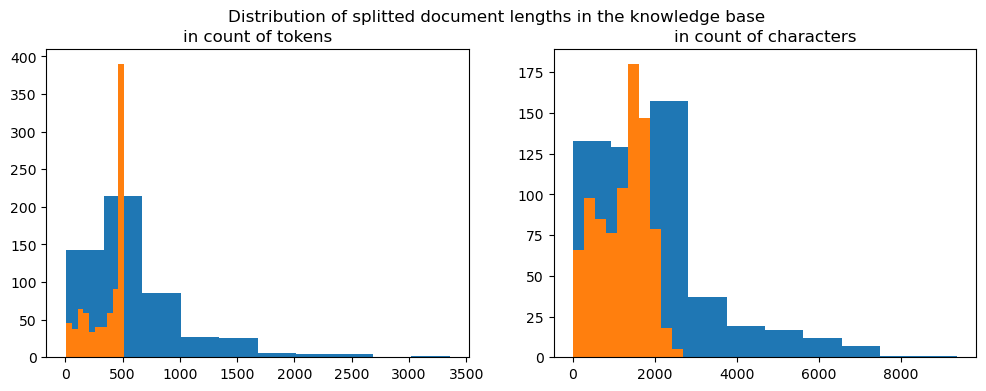

In [38]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1,2, figsize=(12,4))


n_tokens = [len(tokenizer.encode(a.page_content)) for a in docs]
n_tokens_split = [len(tokenizer.encode(a.page_content)) for a in docs_split]
axs[0].hist(n_tokens)
axs[0].hist(n_tokens_split)

axs[0].set_title("in count of tokens")

n_caract = [len(a.page_content) for a in docs]
n_caract_split = [len(a.page_content) for a in docs_split]

axs[1].hist(n_caract)
axs[1].hist(n_caract_split)
axs[1].set_title("in count of characters")

plt.suptitle("Distribution of splitted document lengths in the knowledge base")


In [39]:
from langchain_community.embeddings import HuggingFaceEmbeddings # deprecated
# from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name=tokenizer_name,
    # multi_process=True,
    model_kwargs={"device": "mps"},  # use cuda for faster embeddings on nbidia GPUs
    encode_kwargs={"normalize_embeddings": True},  # Set `True` for cosine similarity
)

/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_29697/3187483442.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_split, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

# Save the vector database
from datetime import datetime 
vector_info = str(chunk_size) + "-" + tokenizer_name.replace("/","-") + "-" + datetime.now().date().isoformat()
KNOWLEDGE_VECTOR_DATABASE.save_local("../data/FAISS/{vector_info}")


AttributeError: 'builtin_function_or_method' object has no attribute 'date'

# load vector store from local to azure blob storgae

In [10]:

def load_vector_store(EMBEDDING_MODEL_NAME,VECTOR_DB_PATH):
    # create the embedding model
    embedding_model = HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL_NAME,
        # multi_process=True,
        model_kwargs={"device": "mps"},  # use cuda for faster embeddings on nbidia GPUs
        encode_kwargs={"normalize_embeddings": True},  # Set `True` for cosine similarity
    )

    
    try:
        # Load the vector database from the folder
        KNOWLEDGE_VECTOR_DATABASE = FAISS.load_local(
            VECTOR_DB_PATH, 
            embedding_model, 
            allow_dangerous_deserialization=True  # Required for security in newer LangChain versions
        )
        return KNOWLEDGE_VECTOR_DATABASE

    except:
        raise "no vector store"

In [9]:



# load files 
from langchain_community.document_loaders import FileSystemBlobLoader
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.parsers import PyPDFParser

# split docs
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document 
from transformers import AutoTokenizer
from typing import List, Optional
from tqdm import tqdm

# create or load embeds
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy

from langchain_community.embeddings import HuggingFaceEmbeddings # deprecated
# from langchain_huggingface import HuggingFaceEmbeddings



EMBEDDING_MODEL_NAME = "intfloat/e5-base-v2"
VECTOR_DB_PATH = "../data/FAISS/512-intfloat-e5-base-v2-2026-01-16"
vector = load_vector_store(EMBEDDING_MODEL_NAME,VECTOR_DB_PATH)

In [2]:
import os
from azure.storage.blob import BlobServiceClient
from langchain_community.vectorstores import FAISS

In [4]:
from dotenv import load_dotenv
load_dotenv

connection_string = os.environ['connection_string']
container_name = os.environ['container_name']
local_path = "../data/FAISS/512-intfloat-e5-base-v2-2026-01-16"


In [ ]:

def upload_index_to_azure(local_folder, container):
    client = BlobServiceClient.from_connection_string(connection_string)
    container_client = client.get_container_client(container)
    
    for filename in os.listdir(local_folder):
        blob_client = container_client.get_blob_client(filename)
        with open(os.path.join(local_folder, filename), "rb") as data:
            blob_client.upload_blob(data, overwrite=True)
    print("Upload complete.")


# 2. Sync to Azure
upload_index_to_azure(VECTOR_DB_PATH, container_name)

Upload complete.


In [1]:
from create_retreiver import *

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [17]:
load_docs("data/source/CV_competences")

Ignoring wrong pointing object 7 0 (offset 0)
Ignoring wrong pointing object 9 0 (offset 0)
Ignoring wrong pointing object 11 0 (offset 0)
Ignoring wrong pointing object 13 0 (offset 0)
Ignoring wrong pointing object 17 0 (offset 0)
Ignoring wrong pointing object 19 0 (offset 0)
Ignoring wrong pointing object 22 0 (offset 0)
Ignoring wrong pointing object 24 0 (offset 0)
Ignoring wrong pointing object 26 0 (offset 0)
Ignoring wrong pointing object 36 0 (offset 0)
Ignoring wrong pointing object 38 0 (offset 0)
Ignoring wrong pointing object 45 0 (offset 0)
Ignoring wrong pointing object 47 0 (offset 0)
Ignoring wrong pointing object 49 0 (offset 0)
Ignoring wrong pointing object 51 0 (offset 0)
Ignoring wrong pointing object 64 0 (offset 0)
Ignoring wrong pointing object 77 0 (offset 0)
Ignoring wrong pointing object 6 0 (offset 0)
Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)
Ignoring wrong pointing object 14 0 (offset 0)
Ignoring wrong p

[Document(metadata={'producer': 'macOS Version 26.2 (assemblage 25C56) Quartz PDFContext', 'creator': 'PyPDF', 'creationdate': "D:20260120104050Z00'00'", 'moddate': "D:20260120104050Z00'00'", 'source': '../data/source/CV_competences/Akkodis-Dossier de compétences.pdf', 'total_pages': 6, 'page': 0, 'page_label': '1'}, page_content='Ce document est la propriété des entités AKKA et Modis, désignées Akkodis, marque commerciale sous laquelle elles opèrent leurs activités. Il ne peut être divulgué ni reproduit sans leur autorisation écrite. CONFIDENTIEL - Modèle TF081 V2.2   - 1 - \nRémi Cazelles DATA SCIENTIST Contact Akkodis : Prénom NOM | Fonction | @mail | Numéro portable          COMPÉTENCES MÉTIER  • Analyses exploratoires de données (EDA) • Analyse statistique et modélisation (ML) • Conception et automatisation de pipelines de données (ETL) • Déploiement de solutions SaaS (API) • Intégration-déploiement continue (CI/CD) • Industrialisation de modèles (MLOPS) • Documentation technique

In [23]:
import os
from dotenv import load_dotenv
load_dotenv()

repos_to_fetch: List[str] = [
            "RCaz33/MCP-1st-Birthday_Hackathon",
            "RCaz33/Smolagent_GAIA_Benchmark", 
            "RCaz33/DataBricks_Hackathon",
            # "RCaz33/Microchip_Health_Monitoring",
            "RCaz33/End-to-end-ML-pipeline",
            "RCaz33/ExplainableAI_XAI_DogBreedClassification",
            "RCaz33/Time-series_Multiclass-classification_Reservoir-computing-INRIA",
            "RCaz33/Digital_production-line",
            "RCaz33/Pipeline_data_process",
            "RCaz33/Meetings_summaries"]
doc = load_markdowns_from_repos(repos_to_fetch)

In [24]:
urls = ["https://github.com/RCaz33?tab=repositories",
        "https://scholar.google.com/citations?user=0q1atkkAAAAJ&hl=fr",
        "https://cordis.europa.eu/project/id/844746/reporting",
        "https://stochelec.weebly.com/",
        "https://www.linkedin.com/in/rcaz33/recent-activity/all/"]
print("... from urls ...")
urls_docs = load_given_webpages(urls)

... from urls ...


In [3]:
from dotenv import load_dotenv
load_dotenv()

connection_string = os.getenv("AZURE_CONN_STR")
container_name = os.getenv("container_name")
local_path = "../data/FAISS/512-intfloat-e5-base-v2-2026-01-16"

if not connection_string or not container_name:
    raise RuntimeError("Missing Azure connection settings in .env file.")

vector_db_path = "../data/FAISS"  
embeddings_size = 512
embeddings_name = "intfloat/e5-base-v2"

upload_index_to_azure(vector_db_path, container_name,connection_string)

Upload complete.
